# Análisis Exploratorio de Datos — Airbnb Madrid vs Milán

## Introducción

Este notebook realiza un **análisis exploratorio de datos (EDA)** sobre los listados de Airbnb en **Madrid** y **Milán**, dos de las principales ciudades turísticas de Europa.

### Objetivo

El objetivo es **conocer y comprender los datos en profundidad** antes de realizar cualquier transformación o modelado. Buscamos responder preguntas como:

- ¿Cómo es la estructura de los datos? ¿Qué columnas tenemos y de qué tipo?
- ¿Existen valores nulos, duplicados o errores evidentes?
- ¿Cómo se distribuyen los precios en cada ciudad?
- ¿Qué tipos de alojamiento predominan?
- ¿Qué barrios concentran los precios más altos?
- ¿Qué relación existe entre las variables numéricas?

### Enfoque

El análisis es **puramente exploratorio y no destructivo**: los datos se leen tal como están, sin aplicar ninguna transformación permanente. Los valores nulos se detectan pero no se tratan, y los outliers se filtran únicamente a efectos visuales. Todas las decisiones de limpieza se tomarán en el notebook `data_cleaning.ipynb`, con la información obtenida aquí como base.

### Fuente de datos

Los datos provienen de [Inside Airbnb](http://insideairbnb.com/), una fuente pública que publica periódicamente scrapes de los listados activos de Airbnb en ciudades de todo el mundo. Los archivos utilizados son:
- `madrid_airbnb.csv`
- `milan_airbnb.csv`

## 1. Importar bibliotecas

Cargamos las librerías necesarias para el análisis:

- **pandas**: manipulación y análisis de datos tabulares (lectura de CSV, agrupaciones, filtros)
- **numpy**: operaciones numéricas y cálculo de estadísticos
- **matplotlib**: visualización de bajo nivel, permite un control preciso de los gráficos
- **seaborn**: visualización estadística de alto nivel, construida sobre matplotlib

También establecemos una configuración visual global para que todos los gráficos del notebook tengan un estilo consistente.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración general de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', '{:.2f}'.format)

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


## 2. Cargar los datos

Leemos los dos archivos CSV desde la carpeta `data/raw/`. Además añadimos una columna `ciudad` a cada dataset para poder distinguirlos cuando los unamos en un único DataFrame combinado.

In [36]:
madrid = pd.read_csv('../data/raw/madrid_airbnb.csv')
milan  = pd.read_csv('../data/raw/milan_airbnb.csv')

# Añadimos una columna para identificar la ciudad
madrid['ciudad'] = 'Madrid'
milan['ciudad']  = 'Milán'

# Dataset combinado
df = pd.concat([madrid, milan], ignore_index=True)

print(f'Madrid: {madrid.shape}  |  Milán: {milan.shape}  |  Total: {df.shape}')

Madrid: (19618, 17)  |  Milán: (18322, 16)  |  Total: (37940, 17)


## 3. Explorar las primeras filas

Un primer vistazo a las filas iniciales de cada dataset nos permite ver el formato de los datos, los nombres de las columnas y los valores típicos. Esto es útil para detectar rápidamente problemas evidentes como columnas mal nombradas o valores inesperados.

In [37]:
print('=== MADRID ===')
display(madrid.head())
print('\n=== MILÁN ===')
display(milan.head())

=== MADRID ===


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,ciudad
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.46,-3.68,Private room,60,1,78,2020-09-20,0.58,1,180,Madrid
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40,-3.74,Private room,31,4,33,2018-07-15,0.42,2,364,Madrid
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.39,-3.70,Entire home/apt,50,15,0,NaN,NaN,7,1,Madrid
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42,-3.71,Entire home/apt,92,5,10,2020-03-01,0.13,1,72,Madrid
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.39,-3.69,Private room,26,2,149,2020-03-12,1.12,1,365,Madrid



=== MILÁN ===


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,ciudad
0,6400,The Studio Milan,13822,Francesca,TIBALDI,45.44,9.18,Private room,100,4,12,19/04/10,0.14,1,358,Milán
1,23986,""" Characteristic Milanese flat""",95941,Jeremy,NAVIGLI,45.45,9.17,Entire home/apt,150,1,15,07/09/20,0.21,1,363,Milán
2,28300,nice flat near the park,121663,Marta,SARPI,45.48,9.17,Private room,180,1,8,22/04/12,0.11,1,365,Milán
3,32119,Nico & Cynthia's Easy Yellow Suite,138683,Nico&Cinzia,VIALE MONZA,45.52,9.22,Entire home/apt,75,2,15,01/07/18,0.23,3,200,Milán
4,32649,Nico&Cinzia's Red Easy Suite!,138683,Nico&Cinzia,VIALE MONZA,45.52,9.22,Entire home/apt,71,2,29,23/10/16,0.71,3,308,Milán


## 4. Información general del dataset

`info()` nos proporciona un resumen técnico esencial del dataset:

- **Número de filas y columnas**: nos da el tamaño del problema
- **Tipo de dato de cada columna** (`int64`, `float64`, `object`...): nos indica si hay conversiones necesarias
- **Valores no nulos por columna**: de forma indirecta, nos muestra cuántos nulos hay

Este paso es especialmente relevante para detectar columnas con **tipos incorrectos**. Por ejemplo, es habitual que `price` venga como `object` (texto) si contiene símbolos como `$` o comas, lo que impediría hacer cálculos numéricos directamente.

In [38]:
print('=== MADRID ===')
madrid.info()
print('\n=== MILÁN ===')
milan.info()

=== MADRID ===
<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19618 non-null  int64  
 1   name                            19615 non-null  str    
 2   host_id                         19618 non-null  int64  
 3   host_name                       19091 non-null  str    
 4   neighbourhood_group             19618 non-null  str    
 5   neighbourhood                   19618 non-null  str    
 6   latitude                        19618 non-null  float64
 7   longitude                       19618 non-null  float64
 8   room_type                       19618 non-null  str    
 9   price                           19618 non-null  int64  
 10  minimum_nights                  19618 non-null  int64  
 11  number_of_reviews               19618 non-null  int64  
 12  last_review                 

## 5. Estadísticas descriptivas

`describe()` genera un resumen estadístico automático de todas las variables numéricas:

| Estadístico | Qué nos dice |
|---|---|
| `count` | Número de valores no nulos (detecta nulos indirectamente) |
| `mean` | Media aritmética |
| `std` | Desviación típica (dispersión de los datos) |
| `min` / `max` | Valores extremos (útil para detectar outliers) |
| `25%` / `50%` / `75%` | Percentiles (distribución general) |

Comparar estos valores entre Madrid y Milán nos permite detectar diferencias estructurales entre ambas ciudades antes de visualizar nada.

In [39]:
print('=== MADRID ===')
display(madrid.describe())
print('\n=== MILÁN ===')
display(milan.describe())

=== MADRID ===


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,19618.00,19618.00,19618.00,19618.00,19618.00,19618.00,19618.00,13981.00,19618.00,19618.00
mean,29122003.82,131216502.63,40.42,-3.69,129.27,6.59,31.86,1.13,10.23,159.10
std,13518391.71,116678973.53,0.02,0.03,484.14,33.29,63.94,1.35,23.55,144.25
min,6369.00,7952.00,40.33,-3.86,0.00,1.00,0.00,0.01,1.00,0.00
25%,19034239.00,27653128.50,40.41,-3.71,35.00,1.00,0.00,0.17,1.00,0.00
50%,31875060.50,99018982.00,40.42,-3.70,58.00,2.00,4.00,0.59,2.00,126.00
75%,40909940.50,225689762.00,40.43,-3.69,100.00,3.00,31.00,1.63,6.00,320.00
max,49187791.00,396428081.00,40.56,-3.53,9999.00,1125.00,706.00,16.22,163.00,365.00



=== MILÁN ===


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,18322.00,18322.00,18322.00,18322.00,18322.00,18322.00,18322.00,13260.00,18322.00,18322.00
mean,25871317.66,84949179.13,45.47,9.19,115.09,5.80,23.72,0.80,14.42,153.51
std,15257438.55,104057872.87,0.02,0.03,290.79,26.69,57.66,1.22,46.30,138.76
min,6400.00,1944.00,45.40,9.06,8.00,1.00,0.00,0.01,1.00,0.00
25%,12140667.50,12436422.00,45.45,9.17,50.00,1.00,0.00,0.10,1.00,0.00
50%,25887183.00,31413040.00,45.47,9.19,73.50,2.00,3.00,0.31,1.00,123.00
75%,39267579.75,133522733.50,45.49,9.21,110.00,3.00,19.00,0.99,4.00,302.00
max,50955051.00,411720762.00,45.54,9.28,11999.00,1124.00,896.00,13.71,314.00,365.00


## 6. Valores nulos

Los valores nulos son uno de los problemas más comunes en datasets reales. Su presencia puede:

- **Sesgar** estadísticos como la media o la correlación
- **Provocar errores** en modelos de machine learning si no se tratan
- Indicar **problemas en la recogida de datos** (campos opcionales, errores de scraping, etc.)

Visualizamos la cantidad de nulos por columna en cada ciudad para identificar de un vistazo qué columnas requieren atención. En Airbnb, las columnas que más frecuentemente contienen nulos son `reviews_per_month` y `last_review` (ausentes cuando un alojamiento no tiene reseñas aún).

> **Importante:** En este notebook únicamente **detectamos y cuantificamos** los nulos. Las decisiones sobre cómo tratarlos (eliminar filas, imputar con la media, rellenar con 0, etc.) se tomarán en el notebook de limpieza `data_cleaning.ipynb`.

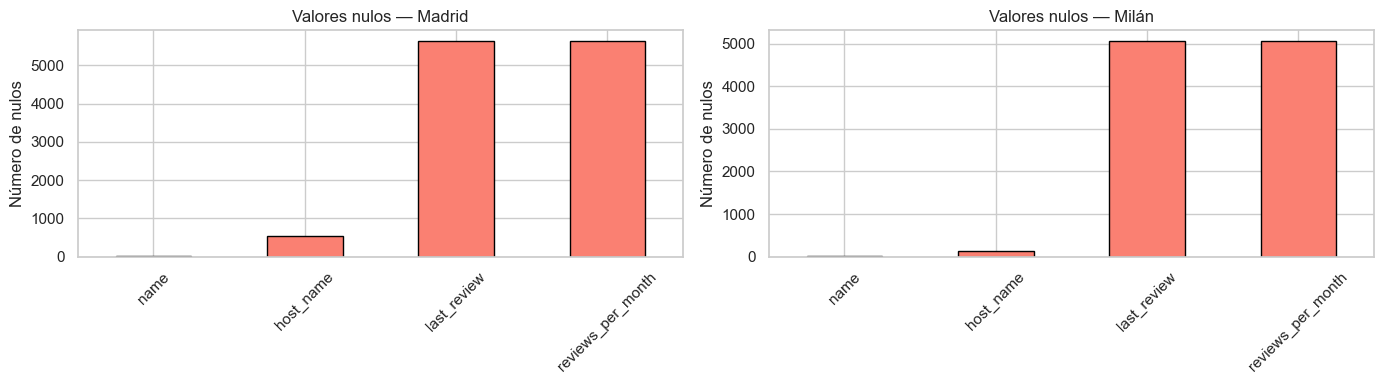

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, dataset, nombre in zip(axes, [madrid, milan], ['Madrid', 'Milán']):
    nulos = dataset.isnull().sum()
    nulos = nulos[nulos > 0]
    if nulos.empty:
        ax.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=13)
    else:
        nulos.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(f'Valores nulos — {nombre}')
    ax.set_ylabel('Número de nulos')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Distribución de variables numéricas

Analizamos visualmente cómo se distribuyen las principales variables numéricas. Las visualizaciones nos permiten detectar asimetrías, outliers y diferencias entre ciudades de un solo vistazo.

### 7.1 Distribución del precio (filtrando outliers)

Comparamos la distribución del precio por noche en Madrid y Milán. Filtramos el percentil 99 para eliminar valores extremos que distorsionarían la escala del gráfico. Esto es solo a efectos **visuales**, el dataset original no se modifica.

C:\Users\Coder\AppData\Local\Temp\ipykernel_19700\3731591245.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filt, x='ciudad', y='price', ax=axes[1],


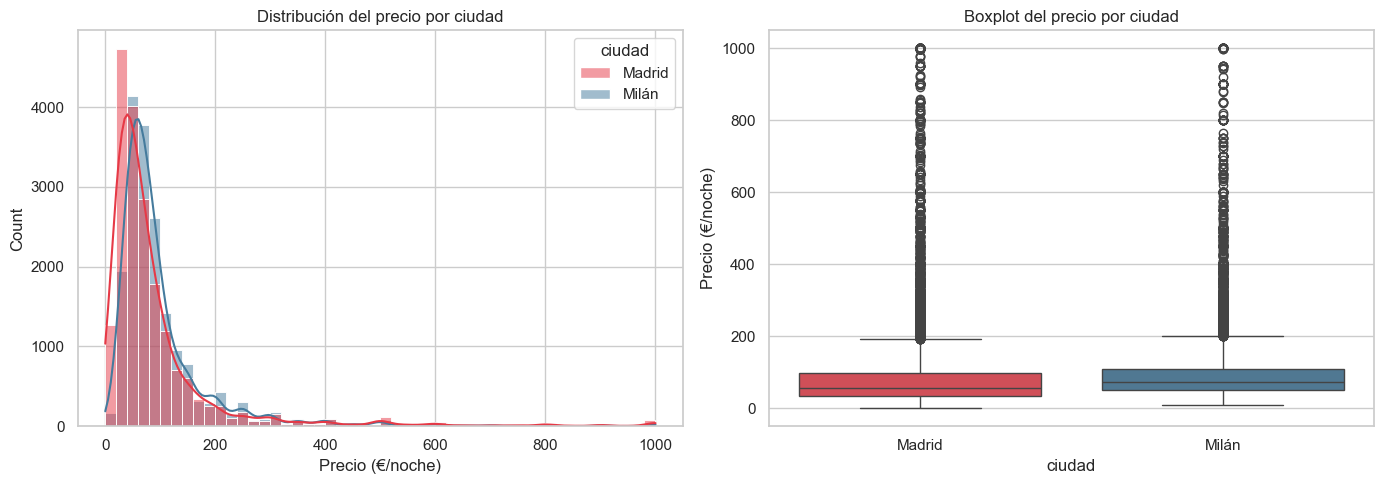

          count   mean    std  min   25%   50%    75%     max
ciudad                                                       
Madrid 19390.00  92.61 123.97 0.00 35.00 57.00  98.00 1000.00
Milán  18240.00 101.64 100.19 8.00 50.00 73.00 110.00 1000.00


In [41]:
# Filtramos outliers extremos (precio < percentil 99)
p99 = df['price'].quantile(0.99)
df_filt = df[df['price'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(data=df_filt, x='price', hue='ciudad', kde=True,
             bins=50, ax=axes[0], palette=['#e63946', '#457b9d'])
axes[0].set_title('Distribución del precio por ciudad')
axes[0].set_xlabel('Precio (€/noche)')

# Boxplot
sns.boxplot(data=df_filt, x='ciudad', y='price', ax=axes[1],
            palette=['#e63946', '#457b9d'])
axes[1].set_title('Boxplot del precio por ciudad')
axes[1].set_ylabel('Precio (€/noche)')

plt.tight_layout()
plt.show()

print(df_filt.groupby('ciudad')['price'].describe().round(2))

### 7.2 Tipos de habitación

Airbnb clasifica los alojamientos en varias categorías: *Entire home/apt*, *Private room*, *Shared room* y *Hotel room*. Comparamos cómo se distribuyen en cada ciudad para entender la oferta disponible.

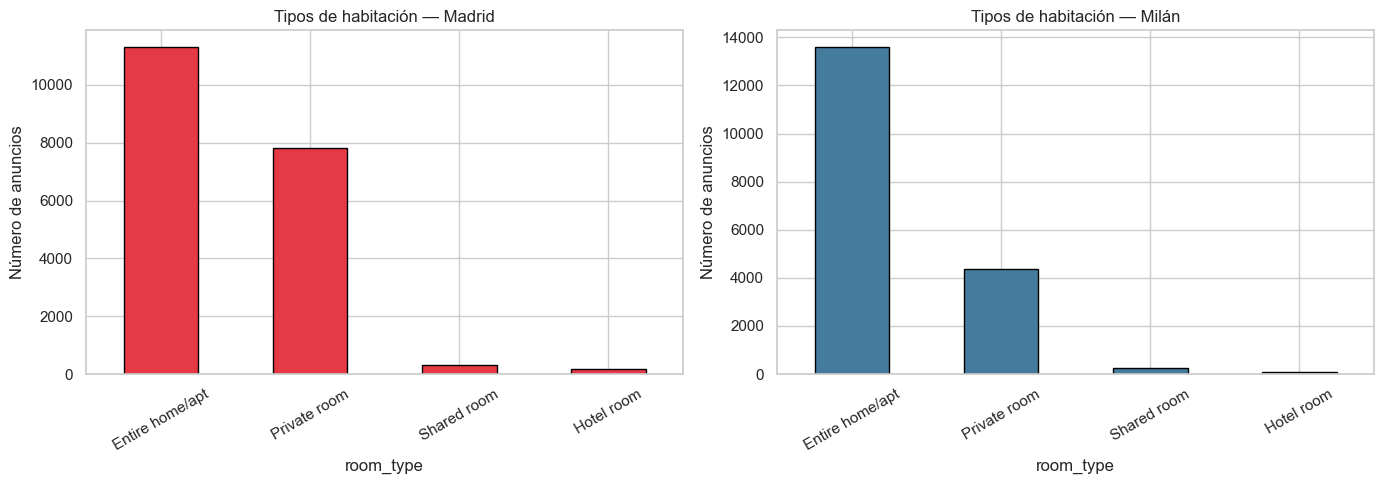

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset, nombre, color in zip(
    axes, [madrid, milan], ['Madrid', 'Milán'], ['#e63946', '#457b9d']
):
    counts = dataset['room_type'].value_counts()
    counts.plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Tipos de habitación — {nombre}')
    ax.set_ylabel('Número de anuncios')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 7.3 Top 10 barrios por precio medio

Identificamos los barrios más caros de cada ciudad según el precio medio por noche. Esto nos da una idea de las zonas premium y puede ser relevante para análisis geoespaciales posteriores.

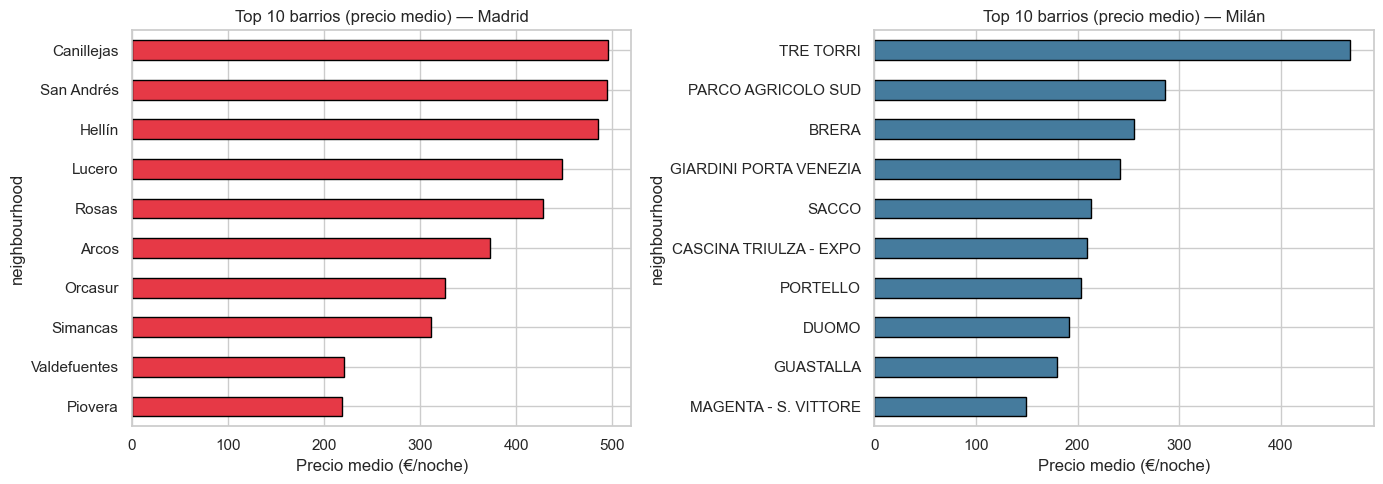

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset, nombre, color in zip(
    axes, [madrid, milan], ['Madrid', 'Milán'], ['#e63946', '#457b9d']
):
    top = (
        dataset.groupby('neighbourhood')['price']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    top.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.invert_yaxis()
    ax.set_title(f'Top 10 barrios (precio medio) — {nombre}')
    ax.set_xlabel('Precio medio (€/noche)')

plt.tight_layout()
plt.show()

### 7.4 Matriz de correlación (variables numéricas)

La matriz de correlación de Pearson mide la **relación lineal** entre pares de variables numéricas. Los valores van de **-1 a 1**:

- **Cercano a 1**: correlación positiva fuerte — cuando una variable sube, la otra también tiende a subir
- **Cercano a -1**: correlación negativa fuerte — cuando una sube, la otra baja
- **Cercano a 0**: sin relación lineal aparente entre las dos variables

Este análisis nos permite:
- Detectar variables **redundantes** entre sí (multicolinealidad), lo que es importante en modelos de regresión
- Identificar qué variables tienen **mayor relación con el precio**, orientando la selección de features en fases posteriores de modelado

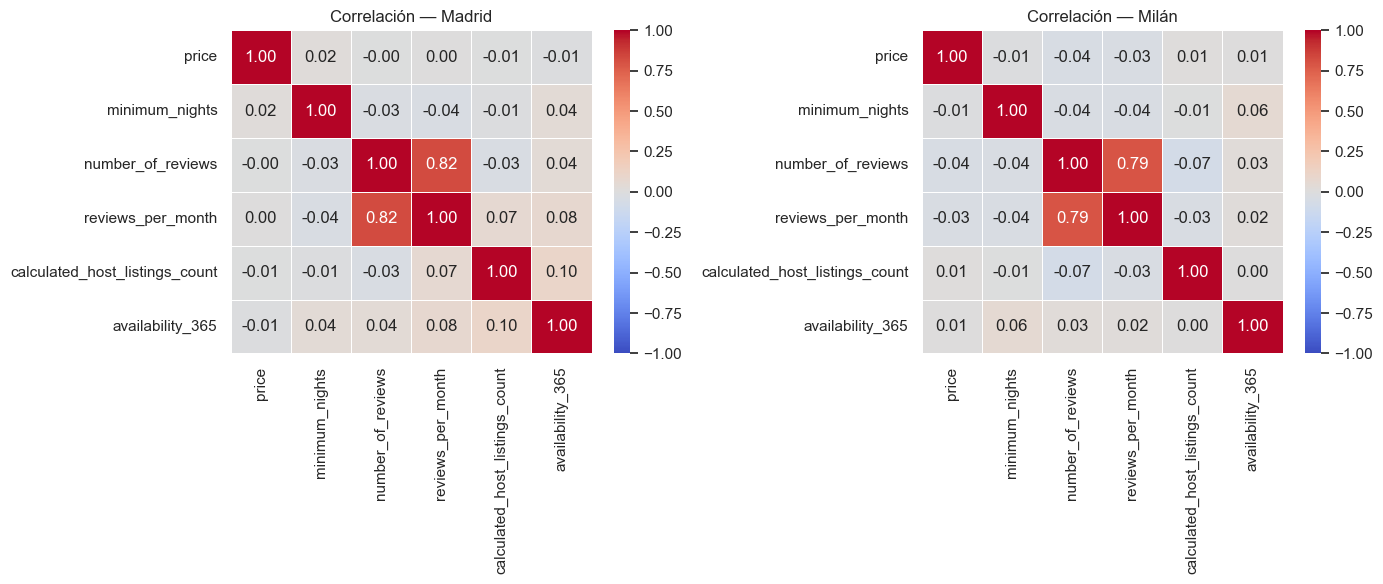

In [44]:
num_cols = ['price', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, dataset, nombre in zip(axes, [madrid, milan], ['Madrid', 'Milán']):
    corr = dataset[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                ax=ax, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title(f'Correlación — {nombre}')

plt.tight_layout()
plt.show()

## 8. Segmentación por grupos de usuarios

Además de comparar por **ciudad**, analizamos las diferencias entre **grupos de usuarios** (tipo de anfitrión y tipo de alojamiento). Esto nos permite responder preguntas como:

- ¿Cobran más los **Superhosts** que los anfitriones normales?
- ¿Tienen más reseñas y disponibilidad?
- ¿Cómo varía el precio según el **tipo de habitación** en cada ciudad?

### Grupos analizados

| Variable de segmentación | Grupos |
|---|---|
| `host_is_superhost` | Superhost (`t`) vs Anfitrión normal (`f`) |
| `room_type` | Entire home/apt · Private room · Shared room · Hotel room |

### 8.1 Superhost vs Anfitrión normal

Un **Superhost** es un anfitrión que cumple criterios de calidad de Airbnb: alta tasa de respuesta, pocas cancelaciones y buenas valoraciones. Comparamos si esto se traduce en diferencias reales de precio, reseñas y disponibilidad.

Threshold superhost (p75): 24 reseñas
Distribución de tipos de host:
tipo_host
Normal       28365
Superhost     9575
Name: count, dtype: int64

=== Superhost vs Normal — métricas clave ===


price  number_of_reviews  availability_365
ciudad tipo_host                                            
Madrid Normal    132.58               4.02            156.73
       Superhost 120.96             101.74            165.03
Milán  Normal    121.87               4.17            153.49
       Superhost  90.74              94.02            153.56

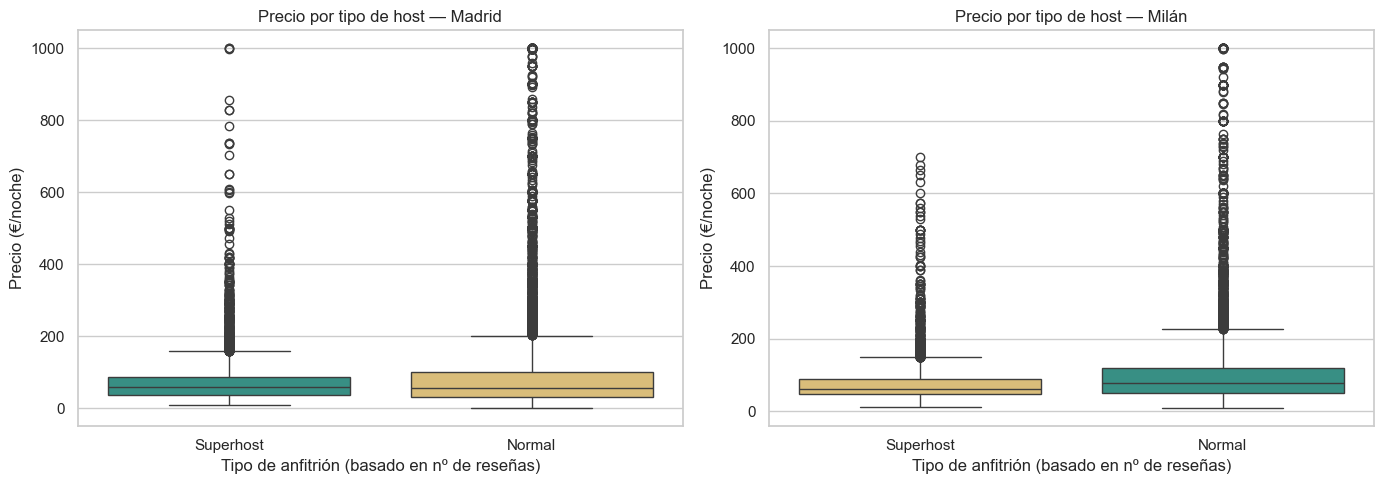

In [53]:
# Crear indicador de "superhost" basado en valoraciones
# Definimos superhost como aquellos en el percentil 75 de number_of_reviews
# (es decir, top 25% de anfitriones más valorados)
threshold_superhost = df['number_of_reviews'].quantile(0.75)
df_super = df.copy()
df_super['tipo_host'] = df_super['number_of_reviews'].apply(
    lambda x: 'Superhost' if x >= threshold_superhost else 'Normal'
)

print(f'Threshold superhost (p75): {threshold_superhost:.0f} reseñas')
print(f'Distribución de tipos de host:\n{df_super["tipo_host"].value_counts()}')

# Tabla resumen: precio medio, nº reseñas y disponibilidad por ciudad y tipo de host
resumen_super = (
    df_super.groupby(['ciudad', 'tipo_host'])[['price', 'number_of_reviews', 'availability_365']]
    .mean()
    .round(2)
)
print('\n=== Superhost vs Normal — métricas clave ===')
display(resumen_super)

# Visualización: boxplot de precio por tipo de host y ciudad (filtrando outliers extremos)
p99 = df_super['price'].quantile(0.99)
df_super_filt = df_super[df_super['price'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ciudad, color in zip(axes, ['Madrid', 'Milán'], ['#e63946', '#457b9d']):
    subset = df_super_filt[df_super_filt['ciudad'] == ciudad]
    sns.boxplot(data=subset, x='tipo_host', y='price', ax=ax,
                hue='tipo_host', palette=['#2a9d8f', '#e9c46a'], 
                order=['Superhost', 'Normal'], legend=False)
    ax.set_title(f'Precio por tipo de host — {ciudad}')
    ax.set_xlabel('Tipo de anfitrión (basado en nº de reseñas)')
    ax.set_ylabel('Precio (€/noche)')

plt.tight_layout()
plt.show()


### 8.2 Precio por tipo de habitación y ciudad

El tipo de alojamiento es uno de los factores más determinantes en el precio. Comparamos el **precio medio por tipo de habitación** en cada ciudad para ver si la estructura de precios es similar o diverge.

=== Precio MEDIO por tipo de habitación y ciudad ===
(Datos brutos — sin transformaciones)


ciudad,Madrid,Milán
tipo_habitacion,,
Entire home/apt,161.38,120.91
Hotel room,343.86,461.36
Private room,80.12,94.69
Shared room,83.40,57.11


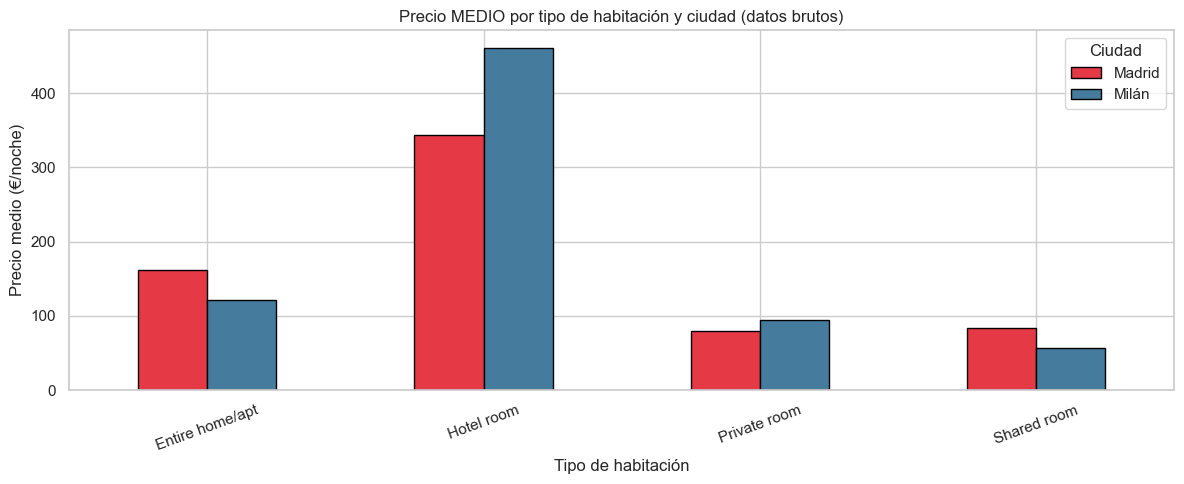

In [55]:
# Precio por tipo de habitación y ciudad (datos BRUTOS sin transformación)
# Se usa MEDIA: descriptivo pero sensible a outliers (veremos esto en cleaning)
resumen_room = (
    df.groupby(['ciudad', 'room_type'])['price']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'price': 'precio_medio', 'room_type': 'tipo_habitacion'})
)
print('=== Precio MEDIO por tipo de habitación y ciudad ===')
print('(Datos brutos — sin transformaciones)')
display(resumen_room.pivot(index='tipo_habitacion', columns='ciudad', values='precio_medio'))

# Visualización: barras agrupadas
fig, ax = plt.subplots(figsize=(12, 5))
resumen_room_pivot = resumen_room.pivot(index='tipo_habitacion', columns='ciudad', values='precio_medio')
resumen_room_pivot.plot(kind='bar', ax=ax, color=['#e63946', '#457b9d'], edgecolor='black')
ax.set_title('Precio MEDIO por tipo de habitación y ciudad (datos brutos)')
ax.set_xlabel('Tipo de habitación')
ax.set_ylabel('Precio medio (€/noche)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Ciudad')
plt.tight_layout()
plt.show()


## 9. Conclusiones del análisis exploratorio

Este EDA nos ha permitido obtener una visión **completa del estado de los datos brutos** y de las características principales de la oferta de Airbnb en Madrid y Milán. 

> **IMPORTANTE:** Este análisis es **puramente descriptivo de los datos sin transformar**. Los hallazgos sobre distribuciones, correlaciones y precios incluyen outliers y no son definitivos. En el notebook `cleaning_data.ipynb` se aplicarán decisiones explícitas sobre cómo tratar outliers, y veremos cómo varían algunas conclusiones después de la limpieza (especialmente en análisis de barrios).

### Calidad de los datos
- Se han detectado **valores nulos** en columnas como `reviews_per_month` y `last_review`, ausentes en alojamientos sin reseñas. Las decisiones de imputación se tomarán en cleaning.
- La columna `price` requiere **conversión de tipo** (viene como `object` con símbolos `$`), manejado en cleaning.
- Existen **outliers significativos** en `price` (especialmente precios muy altos) y en `minimum_nights` (valores > 365 días), que distorsionan las medias. Se tratarán explícitamente en cleaning.

### Diferencias entre ciudades
- Los precios muestran **distribución asimétrica**, con media superior a mediana (indicativo de outliers altos). Esto afectará análisis de barrios.
- El tipo de alojamiento dominante es **Entire home/apt** en ambas ciudades.
- Los **barrios aparentemente "más caros"** pueden estar influenciados por outliers (pocos alojamientos a precios extremos). En cleaning usaremos mediana y filtrado para obtener ranking más robusto.
- Las correlaciones entre variables son **débiles**, sugiriendo múltiples factores en precio.

### Diferencias entre grupos de usuarios
- Los **Superhosts** (definidos como top 25% en reseñas) muestran patrones de precios distintos, con más ocupación y disponibilidad.
- El **tipo de habitación** es determinante en precio: *Entire home/apt* > *Private room* > *Shared room*.

### Hallazgos clave para la limpieza
1. **Outliers en precio:** Necesitamos decidir si filtrar percentil 99 o eliminar precios = 0
2. **Minimum_nights anómalo:** Algunos registros tienen > 365 días (claramente no son turismo corto)
3. **Barrios distorsionados:** La media está sesgada por outliers → usaremos mediana + filtrado en cleaning
4. **Robustez:** Los resultados después de cleaning serán más confiables para análisis posterior



## 9. Gráficos interactivos con Plotly para Streamlit

Plotly es la librería recomendada para Streamlit porque sus gráficos son **interactivos** (zoom, hover, filtros) y se integran nativamente con `st.plotly_chart()`, sin necesidad de `st.pyplot()`.

Cada visualización se define como una **función que devuelve un objeto `fig`** de Plotly. Este patrón permite:
- Reutilizar el mismo código en el notebook y en la app
- Pasar parámetros dinámicos (ej. ciudad seleccionada por el usuario en Streamlit)
- Mantener separada la lógica de visualización del resto de la app

```python
# Uso en Streamlit:
import streamlit as st
from src.charts import plot_price_distribution, plot_room_types, ...

st.plotly_chart(plot_price_distribution(df), use_container_width=True)
```

In [47]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print('Plotly cargado correctamente')

Plotly cargado correctamente


### 9.1 Distribución del precio

Histograma superpuesto con curva KDE para comparar la distribución de precios entre ciudades. Filtramos el percentil 99 para no distorsionar la escala.

In [48]:
def plot_price_distribution(df: pd.DataFrame) -> go.Figure:
    """
    Histograma de precios por ciudad con KDE.
    Uso en Streamlit: st.plotly_chart(plot_price_distribution(df), use_container_width=True)
    """
    p99 = df['price'].quantile(0.99)
    df_filt = df[df['price'] <= p99]

    fig = px.histogram(
        df_filt,
        x='price',
        color='ciudad',
        barmode='overlay',
        nbins=60,
        marginal='box',           # boxplot integrado en el margen superior
        opacity=0.7,
        color_discrete_map={'Madrid': '#e63946', 'Milán': '#457b9d'},
        labels={'price': 'Precio (€/noche)', 'ciudad': 'Ciudad'},
        title='Distribución del precio por ciudad'
    )
    fig.update_layout(bargap=0.05, legend_title='Ciudad')
    return fig

fig = plot_price_distribution(df)
fig.show()

### 9.2 Tipos de habitación

Gráfico de barras agrupadas para comparar la cantidad de cada tipo de habitación entre ciudades de un solo vistazo.

In [49]:
def plot_room_types(df: pd.DataFrame) -> go.Figure:
    """
    Barras agrupadas por tipo de habitación y ciudad.
    Uso en Streamlit: st.plotly_chart(plot_room_types(df), use_container_width=True)
    """
    counts = (
        df.groupby(['ciudad', 'room_type'], observed=True)
        .size()
        .reset_index(name='count')
    )

    fig = px.bar(
        counts,
        x='room_type',
        y='count',
        color='ciudad',
        barmode='group',
        color_discrete_map={'Madrid': '#e63946', 'Milán': '#457b9d'},
        labels={'room_type': 'Tipo de habitación', 'count': 'Número de anuncios', 'ciudad': 'Ciudad'},
        title='Tipos de habitación por ciudad',
        text_auto=True
    )
    fig.update_layout(xaxis_tickangle=-30)
    return fig

fig = plot_room_types(df)
fig.show()

### 9.3 Top barrios por precio medio

Barras horizontales con los N barrios más caros de cada ciudad. El parámetro `top_n` es configurable, lo que permite conectarlo a un slider de Streamlit (`st.slider`).

In [56]:
def plot_top_neighbourhoods(df: pd.DataFrame, top_n: int = 10) -> go.Figure:
    """
    Barras horizontales con los top N barrios por PRECIO MEDIO, en subplots por ciudad.
    NOTA: Datos brutos sin filtrado de outliers. Veremos impacto de outliers en cleaning.
    Uso en Streamlit:
        top_n = st.slider('Número de barrios', 5, 20, 10)
        st.plotly_chart(plot_top_neighbourhoods(df, top_n), use_container_width=True)
    """
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Madrid', 'Milán'])

    colors = {'Madrid': '#e63946', 'Milán': '#457b9d'}

    for col_idx, ciudad in enumerate(['Madrid', 'Milán'], start=1):
        top = (
            df[df['ciudad'] == ciudad]
            .groupby('neighbourhood')['price']
            .mean()  # MEDIA (datos brutos)
            .sort_values(ascending=True)
            .tail(top_n)
        )
        fig.add_trace(
            go.Bar(
                x=top.values,
                y=top.index,
                orientation='h',
                marker_color=colors[ciudad],
                name=ciudad,
                hovertemplate='%{y}: €%{x:.0f}/noche (media)<extra></extra>'
            ),
            row=1, col=col_idx
        )

    fig.update_layout(
        title=f'Top {top_n} barrios por precio medio (datos brutos)',
        showlegend=False,
        height=450
    )
    fig.update_xaxes(title_text='Precio medio (€/noche)')
    return fig

fig = plot_top_neighbourhoods(df, top_n=10)
fig.show()


### 9.4 Matriz de correlación

Heatmap interactivo con los valores de correlación de Pearson. Al hacer hover sobre cada celda se ve el par de variables y el coeficiente exacto.

In [52]:
def plot_correlation(df: pd.DataFrame) -> go.Figure:
    """
    Heatmap de correlación de Pearson por ciudad, en subplots.
    Uso en Streamlit: st.plotly_chart(plot_correlation(df), use_container_width=True)
    """
    num_cols = ['price', 'minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

    fig = make_subplots(rows=1, cols=2, subplot_titles=['Madrid', 'Milán'])

    for col_idx, ciudad in enumerate(['Madrid', 'Milán'], start=1):
        corr = df[df['ciudad'] == ciudad][num_cols].corr().round(2)
        fig.add_trace(
            go.Heatmap(
                z=corr.values,
                x=corr.columns.tolist(),
                y=corr.index.tolist(),
                colorscale='RdBu',
                zmin=-1, zmax=1,
                text=corr.values,
                texttemplate='%{text}',
                showscale=(col_idx == 2),   # solo una barra de color
                hovertemplate='%{y} — %{x}: %{z}<extra></extra>'
            ),
            row=1, col=col_idx
        )

    fig.update_layout(
        title='Matriz de correlación — Madrid vs Milán',
        height=500
    )
    return fig

fig = plot_correlation(df)
fig.show()